In [1]:
import warnings
get_ipython().run_line_magic('run', '"/media/nbourg/One Touch/PhD/Separation_HFR_EAC/toolbox.ipynb"')
warnings.filterwarnings('ignore')

# Raw vs. filled data availability

For the DINEOF run, you need to chose a threshold of temporal coverage under which you mask your data. We choose a lower one for RHED simply because there is less data. We think it may impact the quality of reconstruction, I think that the bad reconstructions are not necessarily located far from the coast (i.e. where there is the lower temporal coverage) but that the fewer observations might be an issue everywhere on the domain. But also I dont want to take 3 points so here we are. + If you look at the plot of RHED, the second line is not that far, so its actually not a lot of pixels that have fewer obs.

In [43]:
import numpy as np
import matplotlib.pyplot as plt 
import xarray as xr
import pandas as pd
import glob 

path = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/HFR/Radials/'
path_vectors = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/HFR/Vectors_Filled/'

rhed_daily = xr.open_dataset(path+'RHED'+'/QCed/RHED_daily_Y2019_M07_Y2021_M12.nc')
seal_daily = xr.open_dataset(path+'SEAL'+'/QCed/SEAL_daily_Y2019_M07_Y2021_M12.nc')

currents = xr.open_dataset(path_vectors+'currents_dineof_NEWC_Y2019M07_Y2021M12.nc')

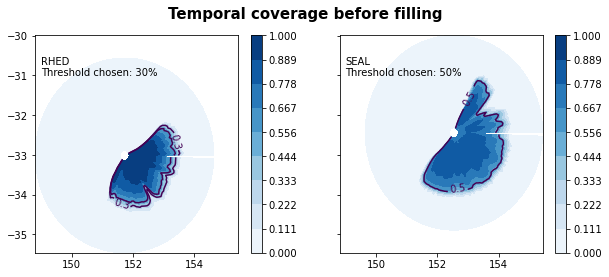

In [42]:
fig,axs = plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,4))
#RHED
pc0=axs[0].contourf(rhed_daily['lon'],
           rhed_daily['lat'],
           get_pixel_coverage(rhed_daily['vr'].values)/rhed_daily['vr'].shape[0],
                   levels=np.linspace(0,1,10),cmap='Blues')

CS = axs[0].contour(rhed_daily['lon'],
           rhed_daily['lat'],
           get_pixel_coverage(rhed_daily['vr'].values)/rhed_daily['vr'].shape[0], [0.3])

CSbis = axs[0].contour(rhed_daily['lon'],
           rhed_daily['lat'],
           get_pixel_coverage(rhed_daily['vr'].values)/rhed_daily['vr'].shape[0], [0.5])

axs[0].clabel(CS, inline=True, fontsize=10)
axs[0].text(149,-31,'RHED\nThreshold chosen: 30%')


#SEAL
pc1=axs[1].contourf(seal_daily['lon'],
           seal_daily['lat'],
           get_pixel_coverage(seal_daily['vr'].values)/seal_daily['vr'].shape[0],
                   levels=np.linspace(0,1,10),cmap='Blues')
CS1 = axs[1].contour(seal_daily['lon'],
           seal_daily['lat'],
           get_pixel_coverage(seal_daily['vr'].values)/seal_daily['vr'].shape[0],[0.5])

axs[1].clabel(CS1, inline=True, fontsize=10)
axs[1].text(149,-31,'SEAL\nThreshold chosen: 50%')

fig.suptitle('Temporal coverage before filling',fontsize=15,fontweight='bold')
fig.colorbar(pc0,ax=axs[0])
fig.colorbar(pc1,ax=axs[1])

Text(0.5, 1.0, 'Currents Filled')

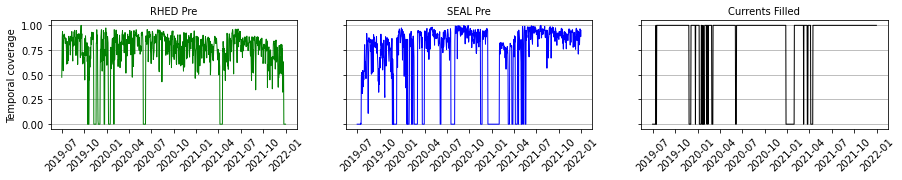

In [180]:
fig,axs = plt.subplots(ncols=3,sharex=True,sharey=True,figsize=(15,2))
for ax in fig.get_axes():
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.grid(zorder=0)

axs[0].plot(rhed_daily['time'].values,
        get_spatial_coverage(rhed_daily['vr'].values)/np.nanmax(get_spatial_coverage(rhed_daily['vr'].values)),
        linewidth=1,
        color='g',
       zorder=3)

axs[1].plot(seal_daily['time'].values,
        get_spatial_coverage(seal_daily['vr'].values)/np.nanmax(get_spatial_coverage(seal_daily['vr'].values)),
        linewidth=1,
        color='b',
       zorder=3)

axs[2].plot(currents['time'].values,
        get_spatial_coverage(currents['v'].values)/np.nanmax(get_spatial_coverage(currents['v'].values)),
        linewidth=1,
        color='k',
       zorder=3)

axs[0].set_ylabel('Temporal coverage')
axs[0].set_title('RHED Pre',fontsize=10)
axs[1].set_title('SEAL Pre',fontsize=10)
axs[2].set_title('Currents Filled', fontsize=10)


In [57]:
ts=np.nanmean(currents['v'].values,axis=(1,2))
print(len(ts[np.isnan(ts)]))

102


In [60]:
ts_rhed=np.nanmean(rhed_daily['vr'].values,axis=(1,2))
ts_seal=np.nanmean(seal_daily['vr'].values,axis=(1,2))
condi = np.logical_or(np.isnan(ts_rhed),np.isnan(ts_seal))
print(len(ts_rhed[condi]))

212


We removed from the reconstruction 102 timesteps out of the 212 times at least one radial was missing (i.e. no currents) because they were not good. It is dommage but we are still happy because of the filling of non-full maps and because of the very important smoothing that the algorithm has done (see pre_post_processing/Check_Dineof_Newcastle_Decides_PostProcess.ipynb for more details).

# Some plots pour se convaincre de la rotation

We noticed that the reconstruction sometimes was making bad stuff, but it was mostly intensifying patterns that already exist. More specifically, there is a cyclonic curvature between the EAC and the coast that we saw oftenly and that was badly intensified during long periods of missing data. We removed it when too intense (see pre_post_processing/Check_Dineof_Newcastle_Decides_PostProcess.ipynb for more details on the definition of too intense), kept it when it seemed ok (in terms of variance). We saw in the radial data that this pattern was present in the data before reconstruction, however to be more sure, following plots show that this feature seems to exist in real life. 

Here is a quiver from IMOS QCed vectorial data off Newcastle, showing a similar rotation.

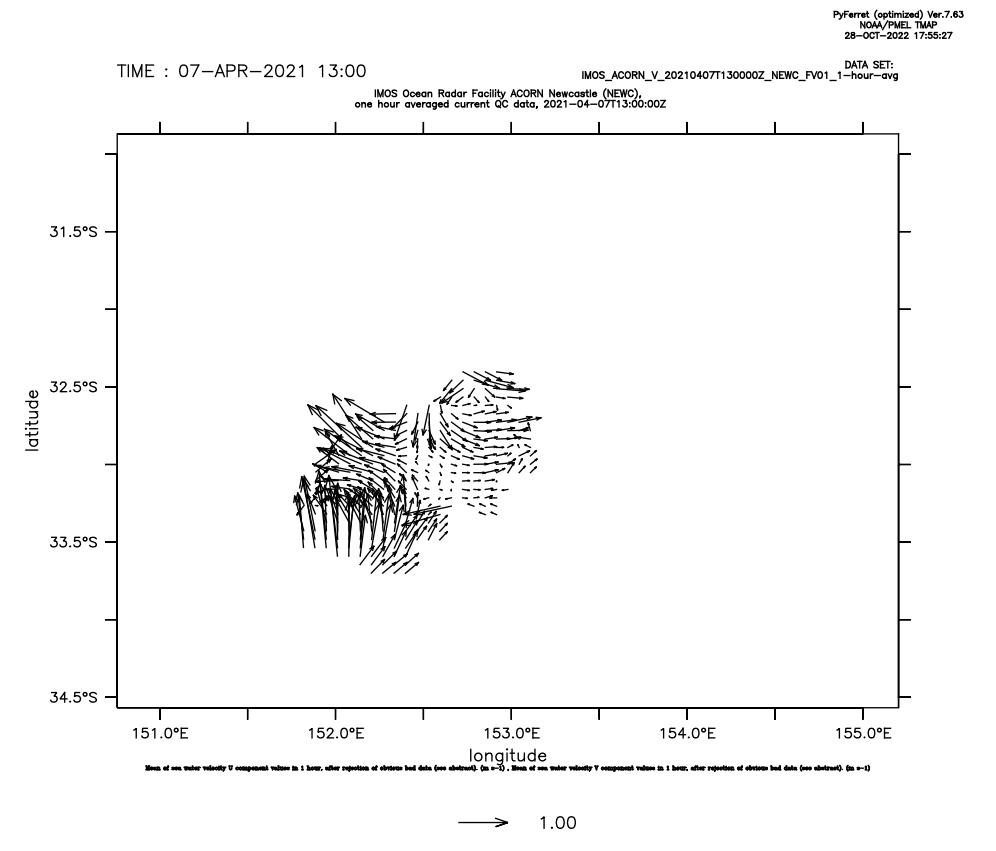

In [194]:
from matplotlib.colors import LinearSegmentedColormap

def build_cmap(name, colors, N=100, reverse=''):
        if reverse == 'r':
                colors = [colors[len(colors)-1-i] for i in range(0, len(colors))]
                cmap = LinearSegmentedColormap.from_list(name, colors, N=N)
        else:
                cmap = LinearSegmentedColormap.from_list(name, colors, N=N)
        return cmap

        
cmap_chl = build_cmap('natacha', [(0/256, 5/256, 34/256),(34/256, 106/256, 234/256),
                (86/256, 196/256, 227/256),(122/256, 218/256, 166/256),
                (246/256, 252/256, 181/256), (255/256, 255/256, 255/256)])


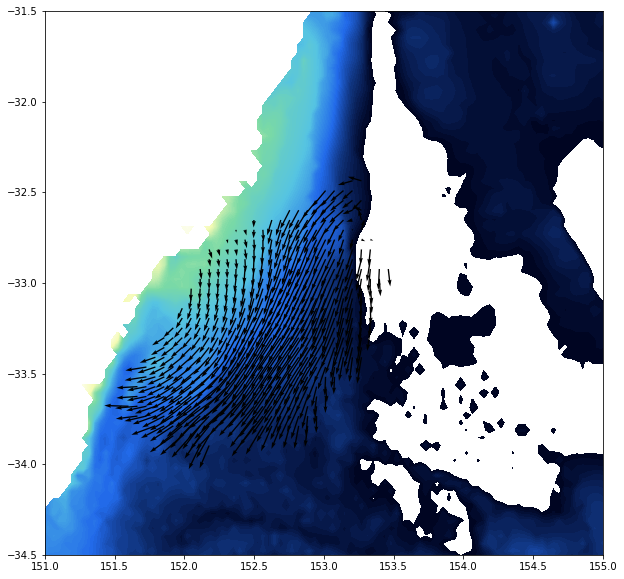

In [234]:
path_chl = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/CHL/'

chl = xr.open_dataset(path_chl+'oc-glo-bio-multi-l4-chl_interpolated_4km_daily_East_Australian_Current_2019_12.nc')

fig,ax=plt.subplots(figsize=(10,10))
ax.set_xlim(151,155)
ax.set_ylim(-34.5,-31.5)
ax.contourf(chl['lon'],chl['lat'],np.log10(chl['CHL'][31-1].values),levels=np.linspace(-1,1,100),cmap=cmap_chl)
q=ax.quiver(currents['lon'],currents['lat'],currents['u'][183],currents['v'][183],units='inches',scale=2)


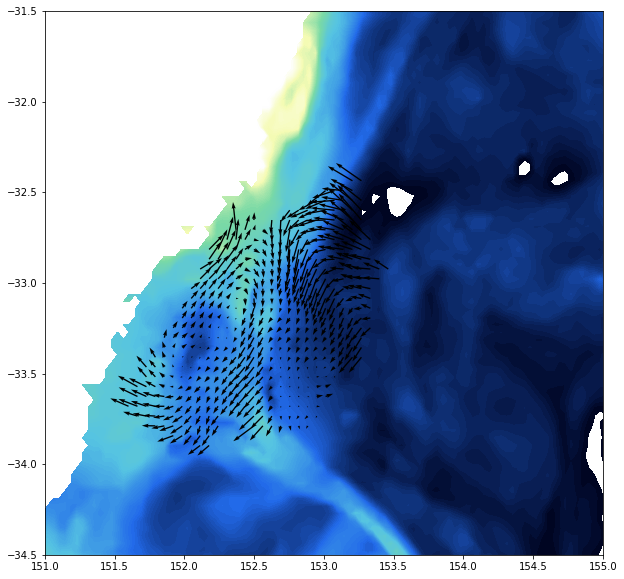

In [233]:
path_chl = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/CHL/'

chl = xr.open_dataset(path_chl+'oc-glo-bio-multi-l4-chl_interpolated_4km_daily_East_Australian_Current_2019_12.nc')
fig,ax=plt.subplots(figsize=(10,10))
ax.set_xlim(151,155)
ax.set_ylim(-34.5,-31.5)
ax.contourf(chl['lon'],chl['lat'],np.log10(chl['CHL'][5-1].values),levels=np.linspace(-1.,.5,100),cmap=cmap_chl)
q=ax.quiver(currents['lon'],currents['lat'],currents['u'][158-1],currents['v'][158-1],units='inches',scale=1)


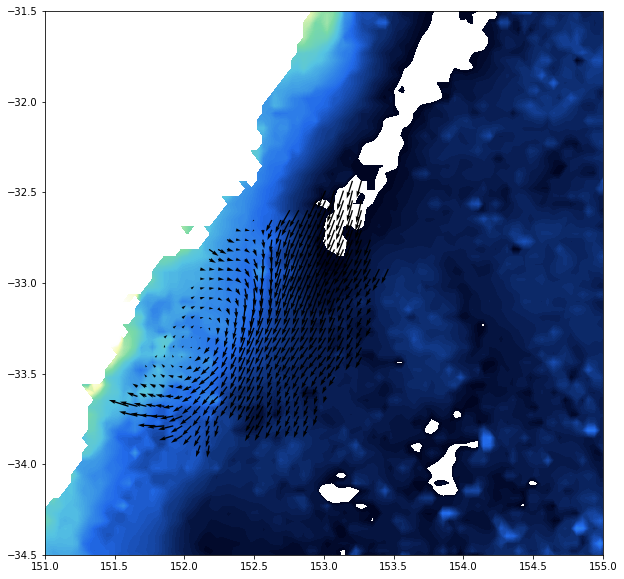

In [232]:
path_chl = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/CHL/'

chl = xr.open_dataset(path_chl+'oc-glo-bio-multi-l4-chl_interpolated_4km_daily_East_Australian_Current_2019_08.nc')
fig,ax=plt.subplots(figsize=(10,10))
ax.set_xlim(151,155)
ax.set_ylim(-34.5,-31.5)
ax.contourf(chl['lon'],chl['lat'],np.log10(chl['CHL'][12-1].values),levels=np.linspace(-.9,.5,100),cmap=cmap_chl)
q=ax.quiver(currents['lon'],currents['lat'],currents['u'][43-1],currents['v'][43-1],units='inches',scale=2)


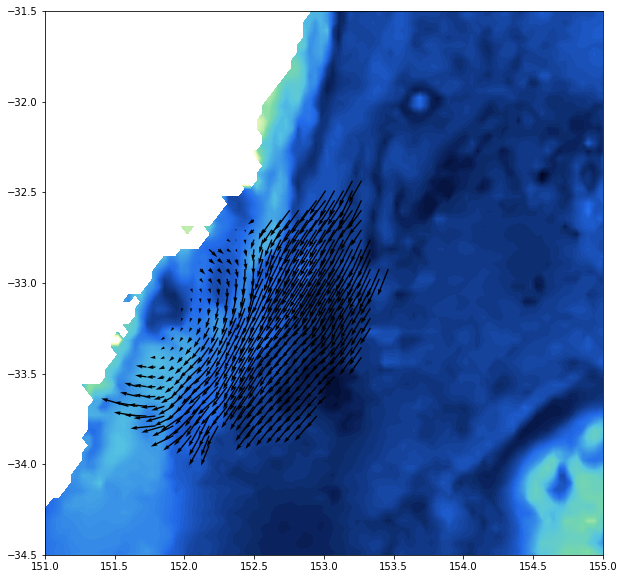

In [231]:
path_chl = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/CHL/'

chl = xr.open_dataset(path_chl+'oc-glo-bio-multi-l4-chl_interpolated_4km_daily_East_Australian_Current_2019_09.nc')
fig,ax=plt.subplots(figsize=(10,10))
ax.set_xlim(151,155)
ax.set_ylim(-34.5,-31.5)
ax.contourf(chl['lon'],chl['lat'],np.log10(chl['CHL'][6-1].values),levels=np.linspace(-.8,1,100),cmap=cmap_chl)
q=ax.quiver(currents['lon'],currents['lat'],currents['u'][68-1],currents['v'][68-1],units='inches',scale=2)


Text(151.1, -32.5, 'Upwelling northwest?')

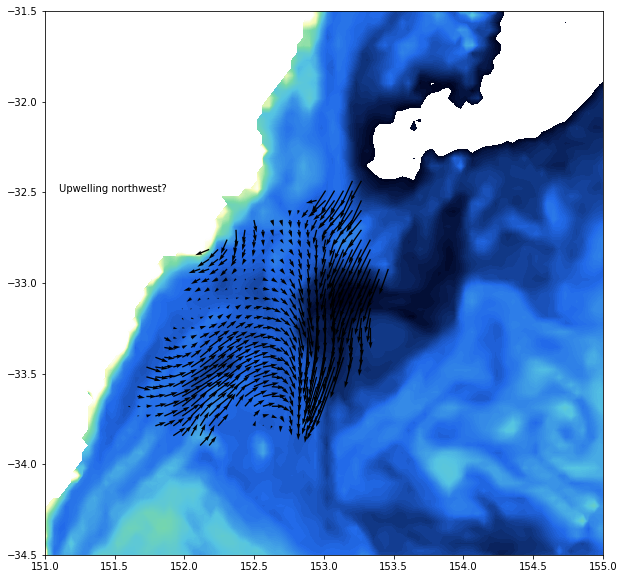

In [219]:
path_chl = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/CHL/'

chl = xr.open_dataset(path_chl+'oc-glo-bio-multi-l4-chl_interpolated_4km_daily_East_Australian_Current_2019_10.nc')
fig,ax=plt.subplots(figsize=(10,10))
ax.set_xlim(151,155)
ax.set_ylim(-34.5,-31.5)
ax.contourf(chl['lon'],chl['lat'],np.log10(chl['CHL'][23-1].values),levels=np.linspace(-1,.01,200),cmap=cmap_chl)
q=ax.quiver(currents['lon'],currents['lat'],currents['u'][115-1],currents['v'][115-1],units='inches',scale=1)
ax.text(151.1,-32.5,'Upwelling northwest?')

# in the middle of a 10 days hole in SEAL

Text(151.1, -32.5, 'Curvature and chl-a entrainment\nnot looking bad')

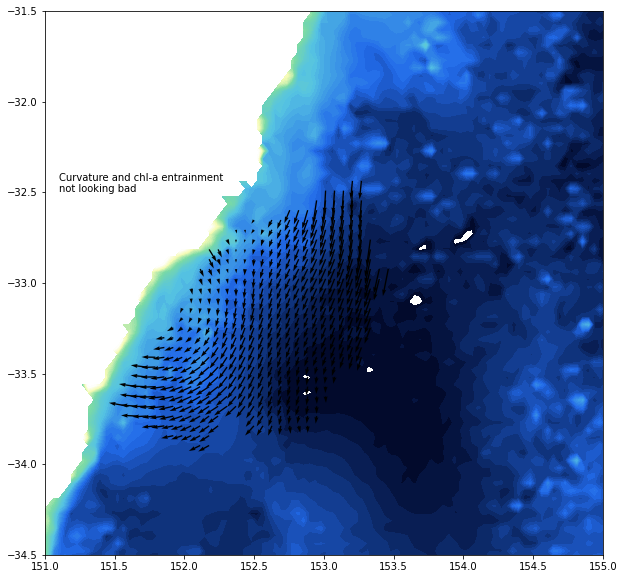

In [220]:
path_chl = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/CHL/'

chl = xr.open_dataset(path_chl+'oc-glo-bio-multi-l4-chl_interpolated_4km_daily_East_Australian_Current_2020_07.nc')

fig,ax=plt.subplots(figsize=(10,10))
ax.set_xlim(151,155)
ax.set_ylim(-34.5,-31.5)
ax.contourf(chl['lon'],chl['lat'],np.log10(chl['CHL'][29-1].values),levels=np.linspace(-1,.5,50),cmap=cmap_chl)
q=ax.quiver(currents['lon'],currents['lat'],currents['u'][395-1],currents['v'][395-1],units='inches',scale=2)
ax.text(151.1,-32.5,'Curvature and chl-a entrainment\nnot looking bad')

# in the middle of a 3 days hole in SEAL

Text(151.1, -32.5, 'Upwelling and northward nutrient poor current\nnot looking bad')

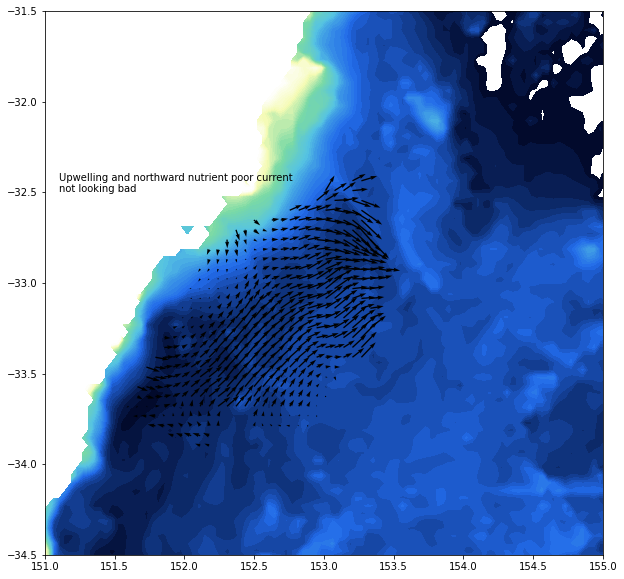

In [221]:
path_chl = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/CHL/'

chl = xr.open_dataset(path_chl+'oc-glo-bio-multi-l4-chl_interpolated_4km_daily_East_Australian_Current_2020_11.nc')

fig,ax=plt.subplots(figsize=(10,10))
ax.set_xlim(151,155)
ax.set_ylim(-34.5,-31.5)
ax.contourf(chl['lon'],chl['lat'],np.log10(chl['CHL'][19-1].values),levels=np.linspace(-1,.5,50),cmap=cmap_chl)
q=ax.quiver(currents['lon'],currents['lat'],currents['u'][508-1],currents['v'][508-1],units='inches',scale=1)
ax.text(151.1,-32.5,'Upwelling and northward nutrient poor current\nnot looking bad')

# in the middle of a 3 days hole in RHED

Text(151.1, -32.5, 'EAC line good, a bit weird at the coast?')

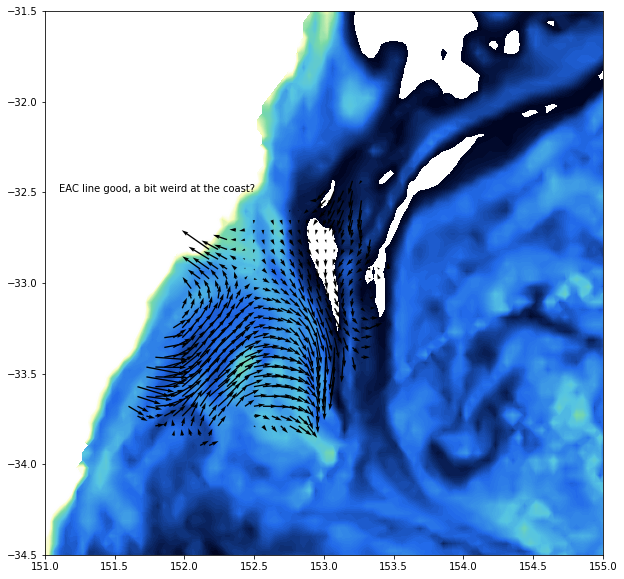

In [228]:
path_chl = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/CHL/'

chl = xr.open_dataset(path_chl+'oc-glo-bio-multi-l4-chl_interpolated_4km_daily_East_Australian_Current_2019_10.nc')

fig,ax=plt.subplots(figsize=(10,10))
ax.set_xlim(151,155)
ax.set_ylim(-34.5,-31.5)
ax.contourf(chl['lon'],chl['lat'],np.log10(chl['CHL'][18-1].values),levels=np.linspace(-0.8,.2,100),cmap=cmap_chl)
q=ax.quiver(currents['lon'],currents['lat'],currents['u'][110-1],currents['v'][110-1],units='inches',scale=1)
ax.text(151.1,-32.5,'EAC line good, a bit weird at the coast?')

# General plots

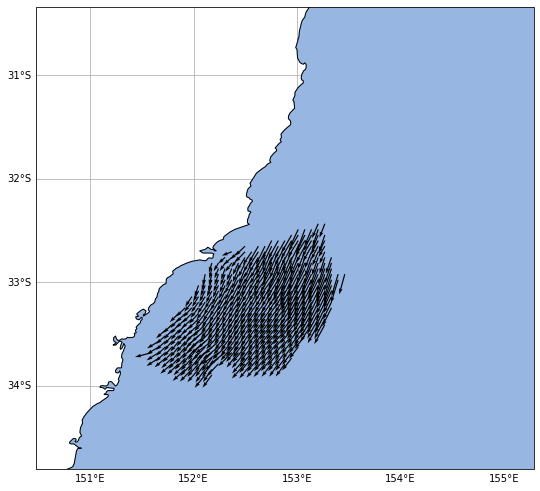

In [272]:
fig,ax=fig_cot_au(1,1)
ax.quiver(currents['lon'],currents['lat'],np.nanmean(currents['u'],axis=0),np.nanmean(currents['v'],axis=0),
          scale=9)

(152.0, 153.5)

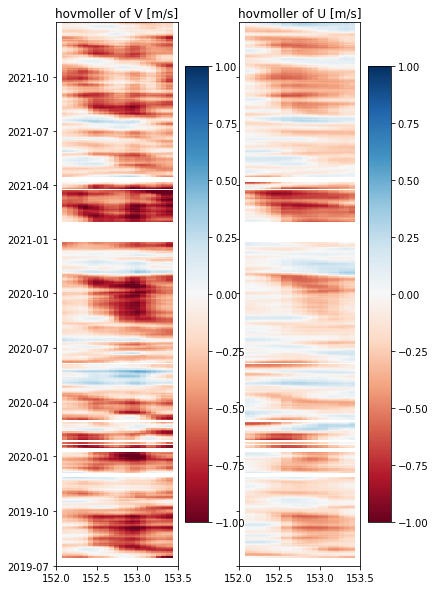

In [266]:
fig,axs=plt.subplots(figsize=(6,10),ncols=2,sharex=True,sharey=True)

pc=axs[0].pcolor(currents['lon'][0,:],currents['time'].values,
           (currents['v'][:,30,:].values),vmin=-1,vmax=1,cmap='RdBu')
axs[0].set_title('hovmoller of V [m/s]')

pc1=axs[1].pcolor(currents['lon'][0,:],currents['time'].values,
           (currents['u'][:,30,:].values),vmin=-1,vmax=1,cmap='RdBu')

axs[1].set_title('hovmoller of U [m/s]')

fig.colorbar(pc,ax=axs[0])
fig.colorbar(pc1,ax=axs[1])

axs[0].set_xlim(152,153.5)
axs[1].set_xlim(152,153.5)
